Date
2000-01-31    1425.585504
2000-02-29    1388.874500
2000-03-31    1442.212599
2000-04-30    1461.355257
2000-05-31    1418.479548
Freq: ME, Name: Close, dtype: float64


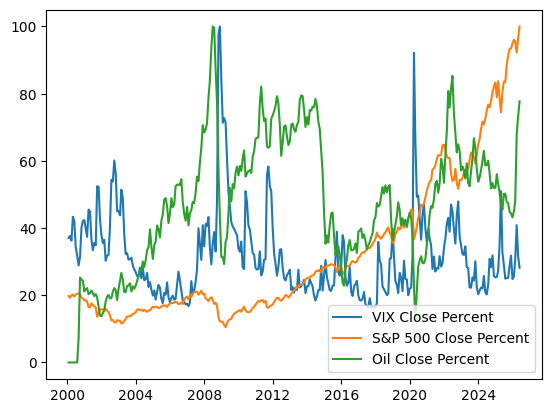

          Date  Name          Open          High           Low         Close  \
0       946857     2      0.000000      0.000000      0.000000      0.000000   
1       946857     1   4186.189941   4192.189941   3989.709961   4131.149902   
2       946857     3   1469.250000   1478.000000   1438.359985   1455.219971   
3       946857     0  11501.849609  11522.009766  11305.690430  11357.509766   
4       946857     4     24.360001     26.150000     23.980000     24.209999   
...        ...   ...           ...           ...           ...           ...   
33135  1777852     2     99.730003    107.459999     99.110001    106.419998   
33136  1777852     1  25112.179688  25210.470703  24913.119141  25067.800781   
33137  1777852     3   7228.379883   7244.540039   7174.120117   7200.750000   
33138  1777852     0  49416.660156  49441.429688  48913.058594  48941.898438   
33139  1777852     4     17.379999     19.080000     17.150000     18.290001   

             Volume  
0      0.000000e+

Depth=0, working on node 6: 100%|██████████| 7/7 [00:00<00:00, 552.61it/s]


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.GraphUtils import GraphUtils

df = pd.read_csv("..\\data\\stock_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.fillna(0, inplace=True)
monthly_df_vix = df.loc[df['Name'] == "VIX", "Close"].resample('ME').mean()
monthly_df_sp = df.loc[df['Name'] == "SandP500", "Close"].resample('ME').mean()
monthly_df_dj = df.loc[df['Name'] == "DowJones", "Close"].resample('ME').mean()
monthly_df_nasdaq = df.loc[df['Name'] == "Nasdaq", "Close"].resample('ME').mean()
monthly_df_oil = df.loc[df['Name'] == "Oil", "Close"].resample('ME').mean()
print(monthly_df_sp.head())
plt.plot(monthly_df_vix.index, (monthly_df_vix.values/max(monthly_df_vix.values))*100, label="VIX Close Percent")
plt.plot(monthly_df_sp.index, (monthly_df_sp.values/max(monthly_df_sp.values))*100, label="S&P 500 Close Percent")
# plt.plot(monthly_df_dj.index, (monthly_df_dj.values/max(monthly_df_dj.values))*100, label="Dow Jones Close Percent")
# plt.plot(monthly_df_nasdaq.index, (monthly_df_nasdaq.values/max(monthly_df_nasdaq.values))*100, label="Nasdaq Close Percent")
plt.plot(monthly_df_oil.index, (monthly_df_oil.values/max(monthly_df_oil.values))*100, label="Oil Close Percent")
plt.legend()
plt.show()


df['Name'] = df['Name'].astype('category').cat.codes
df.reset_index(inplace=True)
df["Date"] = df["Date"].astype('int64') // 10**9
print(df)
data = df.to_numpy()
print(data)
# default parameters
cg = pc(data, node_names=["Date", "Name","Open","High","Low","Close","Volume"])
g, edges = fci(data, node_names=["Date", "Name","Open","High","Low","Close","Volume"])

pyd = GraphUtils.to_pydot(cg.G)
pyd.write_png('simple_test_pc.png')

pyd = GraphUtils.to_pydot(g)
pyd.write_png('simple_test_fci.png')